In [1]:
from src.patient_data_dispatcher import PatientDataDispatcher
from src.core.enums import MileStone, DataFrequency, PatientDataType
from src.evaluation import Evaluation
from src.core.normaliser import Normaliser
from sklearn.preprocessing import MinMaxScaler
from src.core.data_transforms import Transform
from src.model import DMORandomForestRegressor

import numpy as np
import torch

In [2]:
K_FOLDS = 5
N_VISITS = 4

In [3]:
dmo_features = [
    "wb_all_sum",
    "walkdur_all_sum",
    "wbsteps_all_sum",
    "wbdur_all_avg",
    "wbdur_all_p90",
    "wbdur_all_var",
    "cadence_all_avg",
    "strdur_all_avg",
    "cadence_all_var",
    "strdur_all_var",
    "ws_1030_avg",
    "strlen_1030_avg",
    "wb_10_sum",
    "ws_10_p90",
    "wb_30_sum",
    "ws_30_avg",
    "strlen_30_avg",
    "cadence_30_avg",
    "strdur_30_avg",
    "ws_30_p90",
    "cadence_30_p90",
    "ws_30_var",
    "strlen_30_var",
    "wb_60_sum",
]

In [4]:
pdd = PatientDataDispatcher(
    "config/config.yaml",
    dmo_features,
    MileStone.ALL,
    data_frequency=DataFrequency.DAILY,
    physical_subset=True,
    #static_features=static_features
)
ids = list(set(pdd.metadata["Local.Participant"].to_list()))
dmo_data, dmo_labels = pdd.get_patient_data(PatientDataType.MILESTONE, ids=ids)

In [5]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# perform impute on a visit by visit basis, as some visits are completely missing
imputer = IterativeImputer(missing_values=-1, tol=1e-2, keep_empty_features=True)
patients, visits, features, days = dmo_data.shape

for p in range(patients):
    for v in range(visits):
        visit_data = dmo_data[p, v]

        if (visit_data == -1).all():
            continue

        dmo_data[p, v] = torch.from_numpy(imputer.fit_transform(visit_data)).to(dtype=torch.float64)

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [6]:
dmo_data, dmo_labels = Transform.get_patient_visits(dmo_data, dmo_labels, n_visits=N_VISITS)

In [7]:
# remove missing labels
patient_indexs = []
patient, visit, day, features = dmo_data.shape
for p in range(patient):
    all_visits = True
    for v in range(visit):
        data = dmo_data[p, v]
        label = dmo_labels[p, v]
        
        if (data == -1.0).any() or label == -1.0:
            all_visits = False

    if all_visits:
        patient_indexs.append(p)

dmo_data = dmo_data[patient_indexs]
dmo_labels = dmo_labels[patient_indexs]

In [8]:
dmo_data.shape

torch.Size([428, 4, 7, 24])

In [9]:
dmo_data = dmo_data.flatten(start_dim=2, end_dim=3)

In [10]:
dmo_labels.shape

torch.Size([428, 4, 1])

In [11]:
current_features = dmo_data[:, 1:, :]
prev_labels = dmo_labels[:, :-1, :]
X_tensor = torch.cat((current_features, prev_labels), dim=2)
y_tensor = dmo_labels[:, 1:, :]
input_data = X_tensor.reshape(-1, 169)
label_data = y_tensor.reshape(-1)

In [12]:
input_data[0]

tensor([3.5500e+02, 5.4000e+01, 4.1030e+03, 7.2000e+00, 1.6100e+01, 7.1000e+01,
        8.8000e+01, 1.3000e+00, 1.2000e+01, 2.0000e+01, 6.1000e-01, 8.7000e+01,
        1.0100e+02, 7.2000e-01, 8.0000e+00, 5.8000e-01, 8.4000e+01, 8.4000e+01,
        1.3100e+00, 6.5000e-01, 9.1000e+01, 1.3000e+01, 1.0000e+01, 0.0000e+00,
        3.6300e+02, 7.0000e+01, 5.8370e+03, 7.4000e+00, 1.8500e+01, 1.6400e+02,
        8.7000e+01, 1.2900e+00, 1.2000e+01, 2.0000e+01, 6.2000e-01, 8.8000e+01,
        1.1400e+02, 7.7000e-01, 1.7000e+01, 1.0700e+00, 1.3900e+02, 8.9000e+01,
        1.2000e+00, 1.7900e+00, 9.6000e+01, 5.7000e+01, 5.1000e+01, 5.0000e+00,
        3.2100e+02, 5.8000e+01, 4.9070e+03, 6.6000e+00, 1.6000e+01, 1.8500e+02,
        8.9000e+01, 1.2800e+00, 1.3000e+01, 2.0000e+01, 6.6000e-01, 9.2000e+01,
        7.7000e+01, 1.2100e+00, 9.0000e+00, 1.5000e+00, 1.8500e+02, 9.5000e+01,
        1.1400e+00, 1.8200e+00, 1.0000e+02, 3.6000e+01, 3.3000e+01, 6.0000e+00,
        3.1400e+02, 4.9000e+01, 3.8700e+

In [13]:
label_data[0]

tensor(15)

In [14]:
# shuffle
patients, *other = input_data.shape
generator = torch.Generator()
generator.manual_seed(1234)
random_permutation = torch.randperm(patients, generator=generator)

input_data = input_data[random_permutation]
label_data = label_data[random_permutation]

In [16]:
fatigue_input_split = torch.tensor_split(input_data, K_FOLDS)
fatigue_label_split = torch.tensor_split(label_data, K_FOLDS)

prediction_arr = []
actual_arr = []
for split_i in range(K_FOLDS):
    test_label = fatigue_label_split[split_i]
    test_data = fatigue_input_split[split_i]

    train_label = torch.cat(
        [fatigue_label_split[i] for i in range(0, K_FOLDS) if i != split_i]
    )
    train_data = torch.cat(
        [fatigue_input_split[i] for i in range(0, K_FOLDS) if i != split_i]
    )
    
    rf_model = DMORandomForestRegressor(n_trees=500)

    rf_model.train(train_data, train_label)
    score = rf_model.score(test_data, test_label)
    print(score)
    
    prediction = torch.tensor(rf_model.predict(test_data))
    #prediction = (prediction * physical_subset_max)
    
    actual = test_label
    #actual = (test_label * physical_subset_max)
    
    prediction_arr.append(prediction)
    actual_arr.append(actual)

0.5722842085080779
0.6351533988977459
0.5781516768051304
0.5567352793227753
0.5771909287895185


In [17]:
prediction = torch.cat(prediction_arr)
actual = torch.cat(actual_arr)

{'accuracy': 0.022585669781931463, 'Mean Squared Error': 28.761022567749023, 'Mean Absolute Error': 4.16254997253418, 'R^2': 0.5842271304935235}


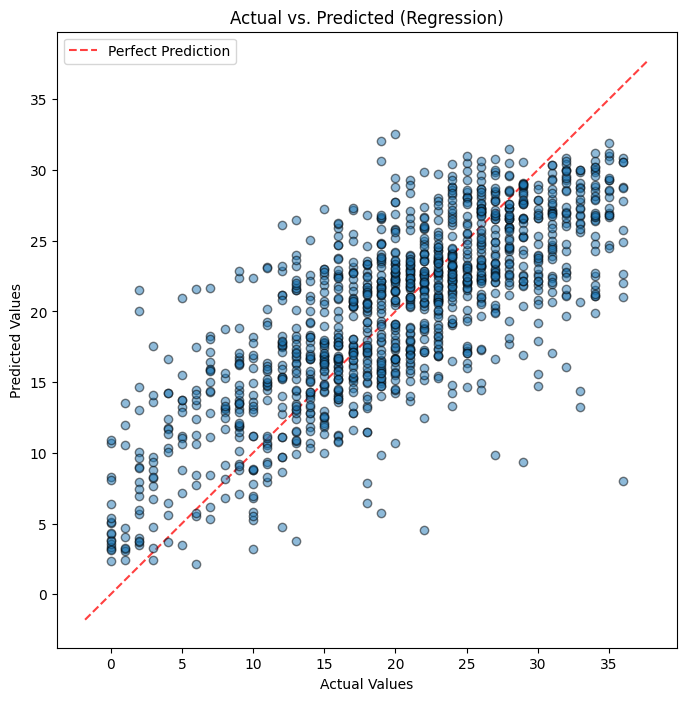

In [18]:
evaluation = Evaluation(prediction, actual)
print(evaluation.compute_all_metrics())
evaluation.evaluation_plot().show()

In [19]:
import shap


features = []

for i in range(1, 5):
    features.extend([*dmo_features, f"MFISV{i}"])

print(features)
random_forest_model = rf_model.random_forest
test_input_numpy = torch.Tensor.numpy(test_input)

explainer = shap.TreeExplainer(random_forest_model)
shap_values = explainer.shap_values(test_input_numpy)
shap.summary_plot(
    shap_values,
    test_input_numpy,
    feature_names=features,
)

['wb_all_sum', 'walkdur_all_sum', 'wbsteps_all_sum', 'wbdur_all_avg', 'wbdur_all_p90', 'wbdur_all_var', 'cadence_all_avg', 'strdur_all_avg', 'cadence_all_var', 'strdur_all_var', 'ws_1030_avg', 'strlen_1030_avg', 'wb_10_sum', 'ws_10_p90', 'wb_30_sum', 'ws_30_avg', 'strlen_30_avg', 'cadence_30_avg', 'strdur_30_avg', 'ws_30_p90', 'cadence_30_p90', 'ws_30_var', 'strlen_30_var', 'wb_60_sum', 'MFISV1', 'wb_all_sum', 'walkdur_all_sum', 'wbsteps_all_sum', 'wbdur_all_avg', 'wbdur_all_p90', 'wbdur_all_var', 'cadence_all_avg', 'strdur_all_avg', 'cadence_all_var', 'strdur_all_var', 'ws_1030_avg', 'strlen_1030_avg', 'wb_10_sum', 'ws_10_p90', 'wb_30_sum', 'ws_30_avg', 'strlen_30_avg', 'cadence_30_avg', 'strdur_30_avg', 'ws_30_p90', 'cadence_30_p90', 'ws_30_var', 'strlen_30_var', 'wb_60_sum', 'MFISV2', 'wb_all_sum', 'walkdur_all_sum', 'wbsteps_all_sum', 'wbdur_all_avg', 'wbdur_all_p90', 'wbdur_all_var', 'cadence_all_avg', 'strdur_all_avg', 'cadence_all_var', 'strdur_all_var', 'ws_1030_avg', 'strlen_1

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NameError: name 'test_input' is not defined

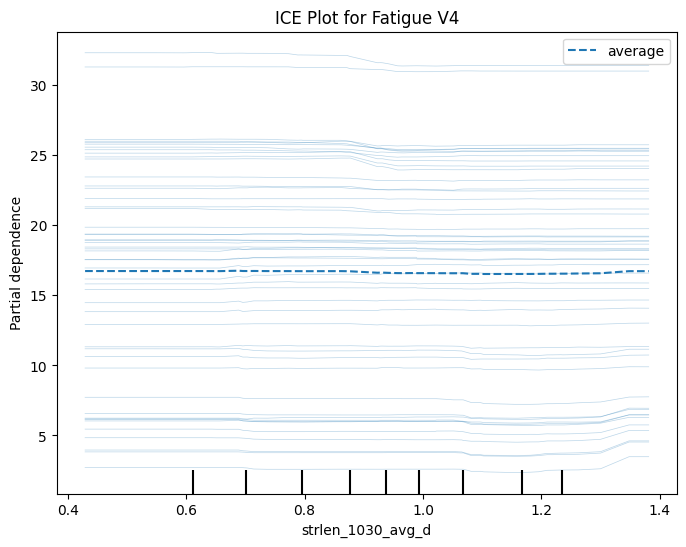

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

feature_index = 3

test_numpy = test_input.numpy()

fig, ax = plt.subplots(figsize=(8, 6))

display = PartialDependenceDisplay.from_estimator(
    random_forest_model, 
    test_numpy, 
    features=[feature_index],
    feature_names=dmo_features,
    kind='both', 
    subsample=50,
    ax=ax
)

ax.set_title("ICE Plot for Fatigue V4")
plt.show()